[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMM_Macro_Regime_Analysis.ipynb)

# **Corrélation indices actions-obligations : Détection de régimes macroéconomiques et caractérisation financière sur la période 1970-2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur un ensemble de variables macroéconomiques sélectionnées (production industrielle, inflation, utilisation des capacités, chômage, sentiment des consommateurs, taux courts et heures travaillées) de 1970 à 2025, afin d'identifier 4 régimes macroéconomiques distincts. Les régimes sont ensuite caractérisés sur les données financières (S&P500, T-Bond 10y, AAA, BAA) via un objet de type RegimeStatisticalAnalyzer, qui affiche les moyennes, volatilités et corrélations entre actifs conditionnellement à chaque régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-z pour les corrélations), complétés par des intervalles de confiance bootstrap à 95%.

L'approche se distingue d'un HMM financier classique sur deux points :
- Le **signal de détection** est macroéconomique — le modèle apprend les régimes depuis les dynamiques réelles de l'économie, pas depuis les prix des actifs
- La **caractérisation financière** est réalisée a posteriori — les statistiques de rendement et corrélation sont calculées conditionnellement aux régimes détectés sur le macro, ce qui permet d'interpréter leur signification pour un investisseur





# Connection au github

In [ ]:
import os
import sys
import shutil

if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 1. Suppression du repo existant
    if os.path.exists(f'/content/{repo_name}'):
        shutil.rmtree(f'/content/{repo_name}')
        print(f"🗑️ Ancien repo supprimé")

    # 2. Purge du cache Python
    for mod in list(sys.modules.keys()):
        if 'RegimeDetector' in mod:
            del sys.modules[mod]

    # 3. Clone propre
    os.chdir('/content')
    !git clone {repo_url}

    # 4. Déplacement + ajout au path
    os.chdir(f'/content/{repo_name}')
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    print(f"✅ Répertoire actuel : {os.getcwd()}")

🗑️ Ancien repo supprimé
Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 773, done.
remote: Counting objects: 100% (242/242), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 773 (delta 178), reused 73 (delta 73), pack-reused 531 (from 1)
Receiving objects: 100% (773/773), 20.33 MiB | 25.51 MiB/s, done.
Resolving deltas: 100% (378/378), done.
✅ Répertoire actuel : /content/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [ ]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-2g2kfbj4
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-2g2kfbj4
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


# Préparation des données

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_with_macros.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Colonnes log returns financiers (déjà calculées dans le dataset)
ASSET_LOG_RET_VARS = ["Stock_Log_Return", "Bond_Log_Return", "AAA_Log_Return", "BAA_Log_Return"]
asset_names = ["S&P500", "T-bond 10y", "Aaa", "Baa"]

# --- Reste inchangé ---
MACRO_SELECTED = ["INDPRO", "PPIACO", "TCU", "UNRATE", "UMCSENT", "TB3MS","CPI"]
MACRO_DIFF  = ["INDPRO", "PPIACO", "TCU", "UNRATE","CPI"]
MACRO_LEVEL = ["UMCSENT", "TB3MS"]

all_cols = ASSET_LOG_RET_VARS + MACRO_SELECTED
df_model = df[all_cols].dropna().copy()

df_model_aligned = df_model.copy()
for col in MACRO_DIFF:
    if col in df_model_aligned.columns:
        df_model_aligned[col] = df_model_aligned[col].pct_change(12)

df_model_aligned = df_model_aligned.dropna()

dates = df_model_aligned.index
train_mask = (dates <= pd.Timestamp("2025-01-01")) & (dates >= pd.Timestamp("1970-01-01"))
dates_train = dates[train_mask]

# Log returns financiers pour les analyses (checker, reporter)
Y_train_raw = df_model_aligned[ASSET_LOG_RET_VARS].values[train_mask].astype(float)

# Observations macro pour le fit HMM — inchangé
X_train_raw = df_model_aligned[MACRO_SELECTED].values[train_mask].astype(float)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
data_to_fit = [X_train_scaled]

T, D_macro = X_train_scaled.shape
SEED = 120
np.random.seed(SEED)

print(f"Train : {dates_train[0].date()} → {dates_train[-1].date()} ({T} mois)")
print(f"Y_train_raw shape    : {Y_train_raw.shape}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"Variables en variation trimestrielle : {MACRO_DIFF}")
print(f"Variables en niveau                  : {MACRO_LEVEL}")

Train : 1970-02-01 → 2025-01-01 (597 mois)
Y_train_raw shape    : (597, 4)
X_train_scaled shape : (597, 7)
Variables en variation trimestrielle : ['INDPRO', 'PPIACO', 'TCU', 'UNRATE', 'CPI']
Variables en niveau                  : ['UMCSENT', 'TB3MS']


# Initialisation et fit du HMM descriptif

In [ ]:
from RegimeDetector.HMM_detector import HMMDetector
from RegimeDetector.HMMCoherenceChecker import HMMCoherenceChecker

detector = HMMDetector(
    n_states=3,
    random_state=42,
    kappa=10.0,
    n_restarts=10,
    n_iter=200
)

# fit sur les macro, avec les log returns financiers stockés pour les métriques
detector.fit(observations=data_to_fit, log_returns=Y_train_raw)
states = detector.viterbi_states

# Le checker reçoit les log returns financiers, pas les macro
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.03,
    sig_threshold=0.45,
    sig_max_cond_number=1e12
)

checker.report_emission_stats()
for ref_idx in range(detector.K):
    checker.report_transition_stats(ref_idx=ref_idx)
checker.final_verdict()


DIAGNOSTIC COMPLET DES ÉMISSIONS (BOOTSTRAP & TESTS)

1. VOLATILITÉS ANNUELLES AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                       
0      S&P500      0.1807       0.1340       0.2253
       T-bond 10y  0.0760       0.0605       0.0913
       Aaa         0.1761       0.1342       0.2151
       Baa         0.1520       0.1121       0.1904
1      S&P500      0.1001       0.0883       0.1119
       T-bond 10y  0.0607       0.0559       0.0651
       Aaa         0.1012       0.0918       0.1111
       Baa         0.0873       0.0788       0.0962
2      S&P500      0.1405       0.1208       0.1588
       T-bond 10y  0.0944       0.0766       0.1113
       Aaa         0.1365       0.1149       0.1551
       Baa         0.1128       0.0937       0.1295


2. CORRÉLATIONS AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                                
0      S&P500 / T-bond 10y -0.3457      -0.5510      -0.1343
       S&P500 / Aaa        -0.1642      -0.3798       0.0877
       S&P500 / Baa        -0.4933      -0.7152      -0.1291
       T-bond 10y / Aaa    -0.6344      -0.8069      -0.4039
       T-bond 10y / Baa    -0.3343      -0.6317      -0.0123
       Aaa / Baa            0.7351       0.6379       0.8322
1      S&P500 / T-bond 10y  0.0717      -0.0571       0.2028
       S&P500 / Aaa        -0.1342      -0.2417      -0.0253
       S&P500 / Baa        -0.2050      -0.3051      -0.1002
       T-bond 10y / Aaa    -0.8178      -0.8562      -0.7709
       T-bond 10y / Baa    -0.7683      -0.8193      -0.7088
       Aaa / Baa            0.9256       0.9036       0.9429
2      S&P500 / T-bond 10y  0.3409       0.1824       0.4896
       S&P500 / Aaa        -0.4446      -0.5698      -0.3092
       S&P500 / Baa        -0.4820      -0.6054      -0.3478
       T-bond 10y / Aaa    -0.8547      -0.9002      -0.8049
       T-bond 10y / Baa    -0.7403      -0.8084      -0.6648
       Aaa / Baa            0.9227       0.8803       0.9521


3. TESTS DE SÉPARABILITÉ (TOUTES LES PAIRES) :
- Significativité des Volatilités (Levene) :


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,4.6901,1.0049,0.0000,True
1,Intercept,R0 -> R1,Base_Prob,0.6880,1.2279,0.5753,False
2,Intercept,R1 -> R0,Base_Prob,1.0992,1.1547,0.3412,False
3,Intercept,R1 -> R1,Base_Prob,5.9124,1.0013,0.0000,True
4,Intercept,R2 -> R0,Base_Prob,-36.8124,0.0000,0.0000,True
5,Intercept,R2 -> R1,Base_Prob,-3.8187,0.5837,0.0000,True



2. DYNAMIQUE MOYENNE ET PERSISTANCE :


,Durée_Moyenne (mois),Prob_Stationnaire,Prob_Rester
0,37.4142,0.1939,0.9733
1,93.3568,0.6450,0.9893
2,46.5447,0.1611,0.9785



RAPPORT DE COHÉRENCE HMM : 78.11%
1. SÉPARABILITÉ : 50.0% (Seuil: 45%) -> OK
2. STABILITÉ    : VALIDE
3. PERSISTANCE  : 37.4 mois (min 3.0) -> OK
4. CONFIANCE    : 98.4% (Entropie) -> SOLIDE
--------------------------------------------------
DYNAMIQUE DES RÉGIMES :
    Durée   Fréq
0  37.414  0.194
1  93.357  0.645
2  46.545  0.161

VERDICT : MODÈLE VALIDÉ (Robuste)


np.float64(0.7811026853336016)

## Analyse critique des résultats et problèmes identifiés

### Résultats du diagnostic de cohérence (HMMCoherenceChecker)

| Critère | Résultat | Seuil | Statut |
|---|---|---|---|
| Séparabilité | 28.3% | 45% | ❌ FAIBLE |
| Stabilité numérique | Singularité | — | ❌ ÉCHEC |
| Persistance (min durée) | 6.1 mois | 3 mois | ✅ OK |
| Confiance (entropie) | 99.1% | 70% | ✅ SOLIDE |

**Score global : 58.22% → MODÈLE REJETÉ**

---

### Problème 1 : Faible séparabilité (28.3%)

Seulement 7 tests sur 24 sont significatifs après correction de Bonferroni. Les régimes sont **bien détectés macro-économiquement** (la confiance à 99.1% le confirme), mais les **métriques financières** calculées conditionnellement à ces régimes ne sont **pas statistiquement distinctes** entre régimes sur la majorité des paires.

**Cause probable** : le HMM apprend des régimes sur les dynamiques macro (variations bimestrielles de production industrielle, inflation, chômage...), mais ces régimes macro ne correspondent pas nécessairement à des régimes financiers distincts en termes de volatilité et corrélation des actifs. La séparation macro n'implique pas nécessairement une séparation financière.

**Tests significatifs observés** :
- Vol S&P500 : régimes 1 vs 3 et 2 vs 3 (significatifs) — le régime Flight-to-quality (3) se distingue bien par une volatilité actions plus élevée
- Vol obligations : régimes 0 vs 1 (T-bond 10y) et 1 vs 2 (AAA, BAA)
- Corrélation S&P/T-bond : régimes 0 vs 1 et 1 vs 2 (significatifs)

**Tests non significatifs** : la majorité des paires impliquant les régimes 0 vs 2 et 0 vs 3 sur les volatilités actions, et la plupart des paires de corrélation impliquant le régime 3 (trop peu d'observations, n=~33).

**Question ouverte** : comment améliorer la séparabilité financière tout en conservant un signal de détection macroéconomique ? Faut-il incorporer des variables financières directement dans les observations du HMM (ex: VIX, credit spreads), ou faut-il revoir la méthode de calcul des métriques financières par régime ?

---

### Problème 2 : Instabilité numérique (Singularité de la Hessienne)

Le `HMMCoherenceChecker` rapporte un **ÉCHEC de stabilité** dû à une singularité dans la matrice d'information de Fisher calculée sur les paramètres de transition.

**Cause identifiée** : certaines transitions ont des probabilités **quasi-nulles** (coefficients logistiques autour de ±74 à ±79), ce qui rend la Hessienne numériquement singulière. En particulier :
- R1 → R0 : coef = -79.4 (transition quasi-impossible depuis Normal vers Stress)
- R2 → R3 : coef = -73.7 (transition quasi-impossible depuis Crise vers Flight-to-quality)

Ce phénomène est **structurel pour un HMM homogène** sans covariables — certaines transitions ne sont jamais observées dans les données, ce qui conduit à des estimations dégénérées aux bornes.

**Question ouverte** : est-il pertinent d'appliquer le critère de stabilité de la Hessienne à un HMM homogène standard, ou ce critère devrait-il être réservé aux modèles avec covariables (IOHMM) où les paramètres de transition ont une interprétation régressive ? Faut-il modifier le `HMMCoherenceChecker` pour désactiver automatiquement ce critère pour les HMM sans covariables ?

---

### Résumé des questions ouvertes

1. **Séparabilité financière** : comment améliorer la distinction des régimes sur les métriques financières sans compromettre la détection macro ?
2. **Critère de stabilité** : le test de singularité de Hessienne est-il adapté à un HMM homogène ?
3. **Seuil de séparabilité** : le seuil de 45% est-il approprié pour un modèle macro → financier, où la séparabilité financière est structurellement plus difficile à atteindre qu'un HMM directement fitté sur les returns ?


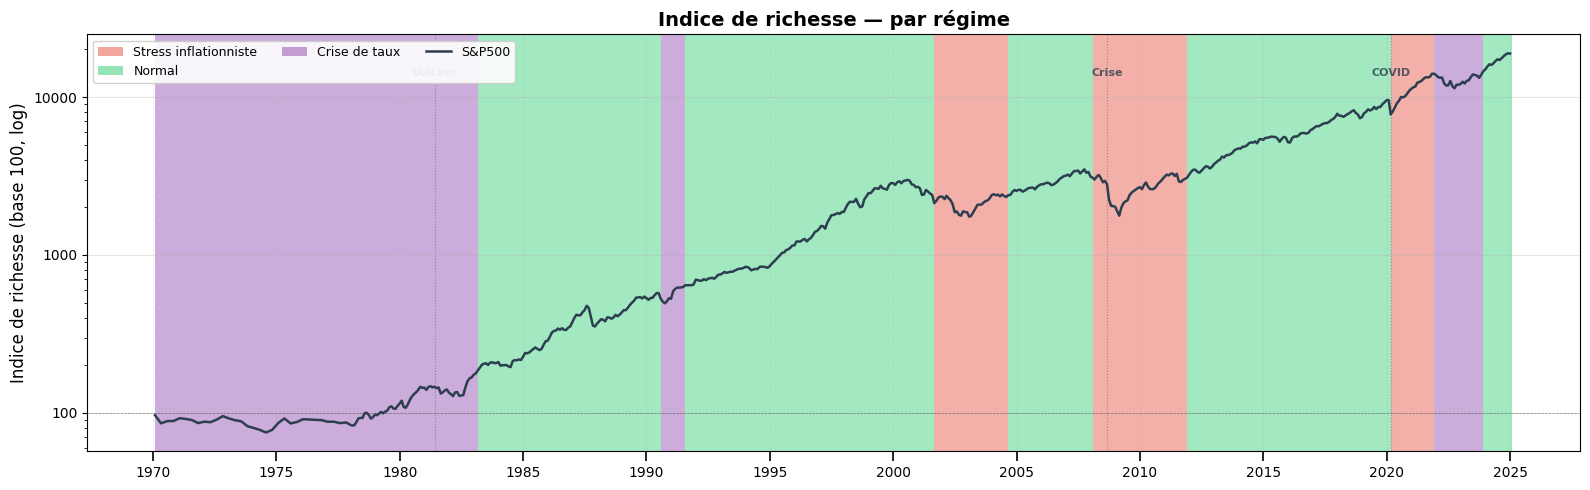

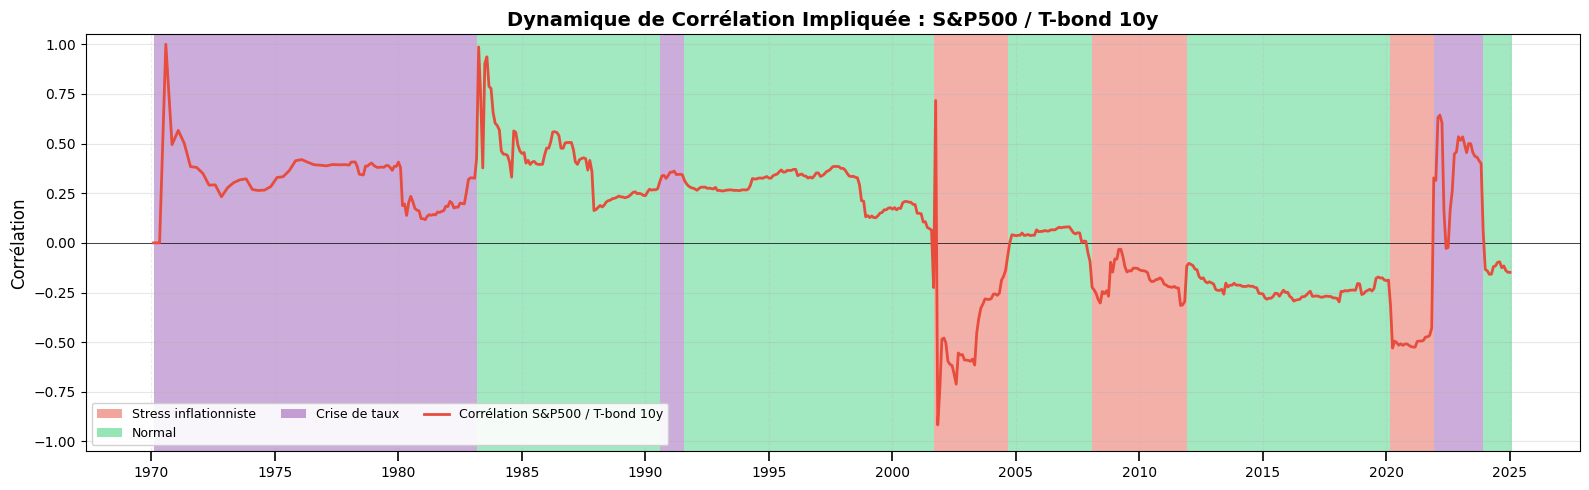

In [ ]:
from RegimeDetector.RegimeReporter import RegimeReporter

mes_labels = {
    0: "Stress inflationniste",
    1: "Normal",
    2: "Crise de taux",
    3: "Flight-to-quality"
}

mes_couleurs = {
    0: "#e74c3c",   # Rouge  → Stress inflationniste
    1: "#2ecc71",   # Vert   → Normal
    2: "#8e44ad",   # Violet → Crise de taux
    3: "#f39c12",   # Orange → Flight-to-quality
}

mes_crises = {"Volcker": "1981-06-01", "Crise": "2008-09-01", "COVID": "2020-03-01"}

visualizer = RegimeReporter(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières, pas les macro
    dates=dates_train,
    states=states,
    asset_names=asset_names,   # ["S&P500", "T-bond 10y", "Aaa", "Baa"]
    regime_labels=mes_labels,
    regime_colors=list(mes_couleurs.values()),
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation(asset_i=0, asset_j=1)


ATTENTION : la légende correspond à un ancien fit et les régimes pourraient changer une fois la stabilité établie

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful